# Fase 2 — Aumentación de Datos
**Entrada:** `arxiv_cs_top10_cleaned.parquet`  
**Salida:** `arxiv_cs_top10_augmented.parquet`

## Estrategia
1. **Back-translation EN→ES→EN** con MarianMT (`Helsinki-NLP/opus-mt-en-es` + `opus-mt-es-en`)  
2. **Paráfrasis con T5** (`t5-base`)

**Objetivo:** igualar todas las clases al volumen de la clase mayoritaria.  

---
## 0. Imports y configuración global

In [6]:
import pandas as pd
import numpy as np
import torch
import random
import os
import time
import warnings
from pathlib import Path
from tqdm.auto import tqdm
from transformers import MarianMTModel, MarianTokenizer, T5ForConditionalGeneration, T5Tokenizer

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

#  Rutas 
DATA_DIR  = Path(r'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset')  
INPUT_FILE  = DATA_DIR / 'arxiv_cs_top10_limpieza_baseline.parquet'
OUTPUT_FILE = DATA_DIR / 'arxiv_cs_top10_augmented.parquet'

#  Hiperparámetros de aumentación 
BATCH_SIZE_BT  = 16    # back-translation: batch size (ajusta según VRAM)
BATCH_SIZE_T5  = 8     # T5 paráfrasis: batch size
MAX_INPUT_LEN  = 256   # tokens de entrada (abstracts arXiv: ~150 palabras)
MAX_OUTPUT_LEN = 280   # tokens de salida generada
NUM_BEAMS      = 4     # beam search
TEMP_T5        = 1.0   # temperatura T5 (1.0 = estocástico moderado)
AUG_CEILING    = 50_000   # techo del balanceo

print(r'\nConfiguracion cargada correctamente.')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3090
VRAM disponible: 25.8 GB
\nConfiguracion cargada correctamente.


---
## 1. Carga y análisis de distribución de clases

In [3]:
df = pd.read_parquet(INPUT_FILE)
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Columnas: {df.columns.tolist()}')
print(f'\nMuestra de texto_limpio (200 chars):')
print(df['texto_limpio'].iloc[0][:200])

Dataset cargado: 642,077 filas × 4 columnas
Columnas: ['title', 'abstract', 'cs_primary', 'texto_limpio']

Muestra de texto_limpio (200 chars):
in a quantum mechanical model diosi feldmann and kosloff arrived at a conjecture stating that the limit of the entropy of certain mixtures is the relative entropy as system size goes to infinity the c


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Distribución de clases 
dist = df['cs_primary'].value_counts().sort_values(ascending=False)
MAX_COUNT = dist.iloc[0]
CLASE_MAYORITARIA = dist.index[0]

print(f'Clase MAYORITARIA: {CLASE_MAYORITARIA} ({MAX_COUNT:,} ejemplos)\n')
print(f'{"Clase":<10} {"Actuales":>10} {"Necesarios":>12} {"% aumento":>10}')
print('-' * 46)

needed = {}
for cls, count in dist.items():
    n = MAX_COUNT - count
    needed[cls] = n
    pct = n / count * 100
    marker = '  ← mayoritaria' if n == 0 else ''
    print(f'{cls:<10} {count:>10,} {n:>12,} {pct:>9.1f}%{marker}')

total_nuevos = sum(needed.values())
print(f'\nTotal de ejemplos nuevos a generar: {total_nuevos:,}')
print(f'Corpus final esperado: {df.shape[0] + total_nuevos:,} filas')

Clase MAYORITARIA: cs.LG (163,515 ejemplos)

Clase        Actuales   Necesarios  % aumento
----------------------------------------------
cs.LG         163,515            0       0.0%  ← mayoritaria
cs.CV         158,670        4,845       3.1%
cs.CL          80,665       82,850     102.7%
cs.IT          46,983      116,532     248.0%
cs.AI          46,299      117,216     253.2%
cs.RO          38,704      124,811     322.5%
cs.CR          33,652      129,863     385.9%
cs.SY          26,912      136,603     507.6%
cs.NA          26,775      136,740     510.7%
cs.DS          19,902      143,613     721.6%

Total de ejemplos nuevos a generar: 993,073
Corpus final esperado: 1,635,150 filas


In [ ]:
#  Visualización: barras antes/después 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
axes[0].barh(dist.index[::-1], dist.values[::-1], color='#5b7fa6')
axes[0].axvline(MAX_COUNT, color='red', linestyle='--', linewidth=1.2, label='Clase mayoritaria')
axes[0].set_title('Distribución original (antes de aumentación)', fontsize=12)
axes[0].set_xlabel('Número de artículos')
axes[0].legend()
for i, (cls, count) in enumerate(zip(dist.index[::-1], dist.values[::-1])):
    axes[0].text(count + 200, i, f'{count:,}', va='center', fontsize=9)

# Después (proyección)
balanced = {cls: MAX_COUNT for cls in dist.index}
axes[1].barh(list(balanced.keys())[::-1], list(balanced.values())[::-1], color='#4a9b7f')
axes[1].set_title('Distribución proyectada (después de aumentación)', fontsize=12)
axes[1].set_xlabel('Número de artículos')
for i, count in enumerate(list(balanced.values())[::-1]):
    axes[1].text(count + 200, i, f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: distribucion_clases.png')

---
## 2. Preparación de candidatos a aumentar

Para cada clase minoritaria se seleccionan aleatoriamente los abstracts a parafrasear.  
Se asegura que **cada abstract se usa como máximo una vez por técnica** para evitar duplicados exactos.

In [7]:
def build_candidates(df: pd.DataFrame, needed: dict, seed: int = SEED) -> dict:
    """
    Para cada clase minoritaria genera una lista de textos candidatos
    a aumentar. Si needed[cls] > len(pool), se hace muestreo con reemplazo
    (con distinto seed por ronda para maximizar diversidad).
    
    Returns:
        dict cls -> lista de textos originales a transformar
    """
    rng = np.random.default_rng(seed)
    candidates = {}
      
    for cls, n_needed in needed.items():
        if n_needed == 0:
            candidates[cls] = []
            continue
        
        pool = df[df['cs_primary'] == cls]['texto_limpio'].tolist()
        
        if n_needed <= len(pool):
            # Muestreo sin reemplazo: máxima diversidad
            idx = rng.choice(len(pool), size=n_needed, replace=False)
            selected = [pool[i] for i in idx]
        else:
            # Muestreo con reemplazo: se necesita más de un pase
            idx = rng.choice(len(pool), size=n_needed, replace=True)
            selected = [pool[i] for i in idx]
        
        candidates[cls] = selected
        print(f'  {cls}: {n_needed:,} candidatos seleccionados '
              f'(pool={len(pool):,}, replace={n_needed > len(pool)})')
    
    return candidates

needed_capped = {cls: max(0, AUG_CEILING - count)
                for cls, count in dist.items()}

print(f'Techo de balanceo: {AUG_CEILING:,} ejemplos por clase\n')
print(f'{"Clase":<10} {"Original":>10} {"Techo":>10} {"Nuevos":>10} {"Ratio":>8}')
print('-' * 54)
for cls, count in dist.items():
    n = needed_capped[cls]
    ratio = n / count if count > 0 else 0
    marker = '  (sin cambio)' if n == 0 else ''
    print(f'{cls:<10} {count:>10,} {AUG_CEILING:>10,} {n:>10,} {ratio:>7.2f}×{marker}')

total_nuevos_capped = sum(needed_capped.values())
print(f'\nTotal a generar (con techo): {total_nuevos_capped:,}')
print(f'Corpus final esperado      : {len(df) + total_nuevos_capped:,}')



print('Construyendo candidatos por clase...')
candidates = build_candidates(df, needed_capped)

total_candidatos = sum(len(v) for v in candidates.values())
print(f'\nTotal de textos a transformar: {total_candidatos:,}')

Techo de balanceo: 50,000 ejemplos por clase

Clase        Original      Techo     Nuevos    Ratio
------------------------------------------------------
cs.LG         163,515     50,000          0    0.00×  (sin cambio)
cs.CV         158,670     50,000          0    0.00×  (sin cambio)
cs.CL          80,665     50,000          0    0.00×  (sin cambio)
cs.IT          46,983     50,000      3,017    0.06×
cs.AI          46,299     50,000      3,701    0.08×
cs.RO          38,704     50,000     11,296    0.29×
cs.CR          33,652     50,000     16,348    0.49×
cs.SY          26,912     50,000     23,088    0.86×
cs.NA          26,775     50,000     23,225    0.87×
cs.DS          19,902     50,000     30,098    1.51×

Total a generar (con techo): 110,773
Corpus final esperado      : 752,850
Construyendo candidatos por clase...
  cs.IT: 3,017 candidatos seleccionados (pool=46,983, replace=False)
  cs.AI: 3,701 candidatos seleccionados (pool=46,299, replace=False)
  cs.RO: 11,296 candidat

### Estrategia de asignación BT vs T5

Se divide el total de candidatos por clase en dos mitades:
- **50% → Back-translation** (BT): mejor para diversidad léxica y sintáctica
- **50% → T5 paráfrasis**: mejor para mantener fidelidad semántica

Si la cantidad a generar es impar, BT recibe el ejemplar extra.

In [8]:
candidates_bt = {}
candidates_t5 = {}

for cls, texts in candidates.items():
    mid = (len(texts) + 1) // 2   # BT recibe el extra si impar
    candidates_bt[cls] = texts[:mid]
    candidates_t5[cls] = texts[mid:]

total_bt = sum(len(v) for v in candidates_bt.values())
total_t5 = sum(len(v) for v in candidates_t5.values())

print(f'Back-translation : {total_bt:,} textos')
print(f'T5 paráfrasis    : {total_t5:,} textos')
print(f'Total            : {total_bt + total_t5:,} textos')

Back-translation : 55,388 textos
T5 paráfrasis    : 55,385 textos
Total            : 110,773 textos


---
## 3. Técnica 1 — Back-Translation EN → ES → EN

In [9]:
#  Carga de modelos MarianMT 
print('Cargando modelos MarianMT...')
t0 = time.time()

MODEL_EN_ES = 'Helsinki-NLP/opus-mt-en-es'
MODEL_ES_EN = 'Helsinki-NLP/opus-mt-es-en'

tok_en_es = MarianTokenizer.from_pretrained(MODEL_EN_ES)
mdl_en_es = MarianMTModel.from_pretrained(MODEL_EN_ES).to(DEVICE)
mdl_en_es.eval()

tok_es_en = MarianTokenizer.from_pretrained(MODEL_ES_EN)
mdl_es_en = MarianMTModel.from_pretrained(MODEL_ES_EN).to(DEVICE)
mdl_es_en.eval()

print(f'Modelos cargados en {time.time()-t0:.1f}s')

Cargando modelos MarianMT...


Loading weights: 100%|████████████████████████████████████████████████████████████| 258/258 [00:00<00:00, 11157.94it/s]
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|████████████████████████████████████████████████████████████| 258/258 [00:00<00:00, 15505.30it/s]
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should u

Modelos cargados en 6.9s


In [10]:
def translate_batch(texts: list, tokenizer, model, max_len: int, num_beams: int) -> list:
    """
    Traduce un batch de textos usando MarianMT.
    Devuelve lista de strings traducidos.
    """
    encoded = tokenizer(
        texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=max_len
    ).to(DEVICE)
    
    with torch.no_grad():
        generated = model.generate(
            **encoded,
            num_beams=num_beams,
            max_length=max_len,
            early_stopping=True
        )
    
    return tokenizer.batch_decode(generated, skip_special_tokens=True)


def back_translate(texts: list,
                   tok_fwd, mdl_fwd,
                   tok_bwd, mdl_bwd,
                   batch_size: int = BATCH_SIZE_BT,
                   max_len: int = MAX_INPUT_LEN,
                   num_beams: int = NUM_BEAMS) -> list:
    """
    Aplica back-translation a una lista de textos.
    EN → ES → EN
    """
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        # EN → ES
        es = translate_batch(batch, tok_fwd, mdl_fwd, max_len, num_beams)
        # ES → EN
        en = translate_batch(es, tok_bwd, mdl_bwd, max_len, num_beams)
        results.extend(en)
    return results


#  Prueba rápida 
test_text = df['texto_limpio'].iloc[0][:300]
test_result = back_translate([test_text], tok_en_es, mdl_en_es, tok_es_en, mdl_es_en)
print('Original :', test_text[:150])
print('BT result:', test_result[0][:150])

Original : in a quantum mechanical model diosi feldmann and kosloff arrived at a conjecture stating that the limit of the entropy of certain mixtures is the rela
BT result: in a mechanical quantum model diosi feldmann and kosloff came to a conjecture claiming that the boundary of entropy of certain mixtures is relative en


In [11]:
#  Aumentación BT por clase 
bt_rows = []   # lista de dicts con las nuevas filas

classes_to_augment_bt = [(cls, texts) for cls, texts in candidates_bt.items() if len(texts) > 0]
print(f'Clases a aumentar con BT: {len(classes_to_augment_bt)}')

for cls, texts in classes_to_augment_bt:
    print(f'\n[BT] {cls}: {len(texts):,} textos...')
    t0 = time.time()
    
    augmented = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE_BT),
                  desc=f'  {cls}', unit='batch'):
        batch = texts[i:i + BATCH_SIZE_BT]
        aug = back_translate(
            batch,
            tok_en_es, mdl_en_es,
            tok_es_en, mdl_es_en,
            batch_size=len(batch)
        )
        augmented.extend(aug)
    
    # Empaquetar como filas del DataFrame
    for i, texto in enumerate(augmented):
        bt_rows.append({
            'id': f'aug_bt_{cls}_{i:06d}',
            'title': '',               # no disponible para aumentados
            'abstract': '',            # original no se preserva aquí
            'cs_primary': cls,
            'texto_limpio': texto,
            'aug_method': 'back_translation'
        })
    
    elapsed = time.time() - t0
    print(f'  Completado en {elapsed:.1f}s ({elapsed/len(texts)*1000:.1f} ms/texto)')

df_bt = pd.DataFrame(bt_rows)
print(f'\nDataFrame BT: {df_bt.shape[0]:,} filas nuevas')

Clases a aumentar con BT: 7

[BT] cs.IT: 1,509 textos...


  cs.IT: 100%|██████████████████████████████████████████████████████████████████████| 95/95 [14:07<00:00,  8.92s/batch]


  Completado en 847.3s (561.5 ms/texto)

[BT] cs.AI: 1,851 textos...


  cs.AI: 100%|████████████████████████████████████████████████████████████████████| 116/116 [16:55<00:00,  8.75s/batch]


  Completado en 1015.6s (548.7 ms/texto)

[BT] cs.RO: 5,648 textos...


...

  Completado en 6479.7s (561.3 ms/texto)

[BT] cs.NA: 11,613 textos...


  cs.NA: 100%|██████████████████████████████████████████████████████████████████| 726/726 [1:45:48<00:00,  8.74s/batch]


  Completado en 6348.1s (546.6 ms/texto)

[BT] cs.DS: 15,049 textos...


  cs.DS: 100%|██████████████████████████████████████████████████████████████████| 941/941 [2:18:22<00:00,  8.82s/batch]

  Completado en 8302.6s (551.7 ms/texto)

DataFrame BT: 55,388 filas nuevas


---
## 4. Técnica 2 — Paráfrasis con T5

In [12]:
#  Liberar memoria GPU antes de cargar T5 
del mdl_en_es, mdl_es_en
torch.cuda.empty_cache()

print('Cargando T5...')
t0 = time.time()

T5_MODEL = 't5-base'   # cambia a 't5-large' si tienes suficiente VRAM

tok_t5 = T5Tokenizer.from_pretrained(T5_MODEL)
mdl_t5 = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)
mdl_t5.eval()

print(f'T5 cargado en {time.time()-t0:.1f}s')
if DEVICE.type == 'cuda':
    alloc = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f'VRAM usada: {alloc:.2f} GB (reservada: {reserved:.2f} GB)')

Cargando T5...


Loading weights: 100%|█████████████████████████████████████████████████████████████| 257/257 [00:00<00:00, 1718.51it/s]


T5 cargado en 13.1s
VRAM usada: 0.90 GB (reservada: 1.00 GB)


In [13]:
def paraphrase_batch_t5(texts: list,
                        tokenizer,
                        model,
                        max_input: int = MAX_INPUT_LEN,
                        max_output: int = MAX_OUTPUT_LEN,
                        num_beams: int = NUM_BEAMS,
                        temperature: float = TEMP_T5) -> list:
    """
    Genera paráfrasis usando T5 con el prefijo 'paraphrase:'.
    Se usa beam search + sampling para diversidad.
    """
    # T5 requiere el prefijo de tarea
    prefixed = [f'paraphrase: {t} </s>' for t in texts]
    
    encoded = tokenizer(
        prefixed,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=max_input
    ).to(DEVICE)
    
    with torch.no_grad():
        out = model.generate(
            **encoded,
            max_length=max_output,
            num_beams=num_beams,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            early_stopping=True
        )
    
    return tokenizer.batch_decode(out, skip_special_tokens=True)


#  Prueba rápida 
test_text2 = df['texto_limpio'].iloc[5][:300]
test_para  = paraphrase_batch_t5([test_text2], tok_t5, mdl_t5)
print('Original   :', test_text2[:150])
print('Paráfrasis :', test_para[0][:150])

Original   : this paper discusses the benefits of describing the world as information especially in the study of the evolution of life and cognition traditional st
Paráfrasis : False


In [14]:
#  Aumentación T5 por clase 
t5_rows = []

classes_to_augment_t5 = [(cls, texts) for cls, texts in candidates_t5.items() if len(texts) > 0]
print(f'Clases a aumentar con T5: {len(classes_to_augment_t5)}')

for cls, texts in classes_to_augment_t5:
    print(f'\n[T5] {cls}: {len(texts):,} textos...')
    t0 = time.time()
    
    augmented = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE_T5),
                  desc=f'  {cls}', unit='batch'):
        batch = texts[i:i + BATCH_SIZE_T5]
        para = paraphrase_batch_t5(batch, tok_t5, mdl_t5)
        augmented.extend(para)
    
    for i, texto in enumerate(augmented):
        t5_rows.append({
            'id': f'aug_t5_{cls}_{i:06d}',
            'title': '',
            'abstract': '',
            'cs_primary': cls,
            'texto_limpio': texto,
            'aug_method': 't5_paraphrase'
        })
    
    elapsed = time.time() - t0
    print(f'  Completado en {elapsed:.1f}s ({elapsed/len(texts)*1000:.1f} ms/texto)')

df_t5 = pd.DataFrame(t5_rows)
print(f'\nDataFrame T5: {df_t5.shape[0]:,} filas nuevas')

Clases a aumentar con T5: 7

[T5] cs.IT: 1,508 textos...


  cs.IT: 100%|████████████████████████████████████████████████████████████████████| 189/189 [11:35<00:00,  3.68s/batch]


  Completado en 695.8s (461.4 ms/texto)

[T5] cs.AI: 1,850 textos...


  cs.AI: 100%|████████████████████████████████████████████████████████████████████| 232/232 [14:46<00:00,  3.82s/batch]


  Completado en 886.9s (479.4 ms/texto)

[T5] cs.RO: 5,648 textos...


...

  Completado en 5503.8s (476.8 ms/texto)

[T5] cs.NA: 11,612 textos...


  cs.NA: 100%|████████████████████████████████████████████████████████████████| 1452/1452 [1:13:20<00:00,  3.03s/batch]


  Completado en 4400.0s (378.9 ms/texto)

[T5] cs.DS: 15,049 textos...


  cs.DS: 100%|████████████████████████████████████████████████████████████████| 1882/1882 [2:01:56<00:00,  3.89s/batch]

  Completado en 7316.7s (486.2 ms/texto)

DataFrame T5: 55,385 filas nuevas


---
## 5. Construcción del corpus aumentado

In [16]:
#  Añadir columna aug_method al DataFrame original 
df_orig = df.copy()
df_orig['aug_method'] = 'original'

#  Concatenar 
df_aug = pd.concat([df_orig, df_bt, df_t5], ignore_index=True)

print(f'Corpus original  : {len(df_orig):>9,} filas')
print(f'Añadido BT       : {len(df_bt):>9,} filas')
print(f'Añadido T5       : {len(df_t5):>9,} filas')
print(f'─────────────────────────────')
print(f'Total aumentado  : {len(df_aug):>9,} filas')
print(f'\nDistribución final:')
print(df_aug['cs_primary'].value_counts().sort_index())

Corpus original  :   642,077 filas
Añadido BT       :    55,388 filas
Añadido T5       :    55,385 filas
─────────────────────────────
Total aumentado  :   752,850 filas

Distribución final:
cs_primary
cs.AI     50000
cs.CL     80665
cs.CR     50000
cs.CV    158670
cs.DS     50000
cs.IT     50000
cs.LG    163515
cs.NA     50000
cs.RO     50000
cs.SY     50000
Name: count, dtype: int64


In [17]:
# ── Análisis de duplicados exactos ────────────────────────────────────────────
total = len(df_aug)
n_duplicados = df_aug.duplicated(subset=['texto_limpio']).sum()
pct_dup = n_duplicados / total * 100

print(f'Total de filas          : {total:,}')
print(f'Duplicados exactos      : {n_duplicados:,} ({pct_dup:.1f}%)')
print(f'Filas únicas            : {total - n_duplicados:,}')

# Desglose por método
print(f'\nDuplicados por método de aumentación:')
for method in ['back_translation', 't5_paraphrase']:
    subset = df_aug[df_aug['aug_method'] == method]
    n_dup = subset.duplicated(subset=['texto_limpio']).sum()
    pct = n_dup / len(subset) * 100 if len(subset) > 0 else 0
    print(f'  {method:<20}: {n_dup:,} / {len(subset):,} ({pct:.1f}%)')

Total de filas          : 752,850
Duplicados exactos      : 43,481 (5.8%)
Filas únicas            : 709,369

Duplicados por método de aumentación:
  back_translation    : 4,568 / 55,388 (8.2%)
  t5_paraphrase       : 38,651 / 55,385 (69.8%)


In [18]:
# ── Duplicados aumentados vs originales ───────────────────────────────────────
# Un sintético que reproduce exactamente un original no aporta nada
originales_set = set(df_aug[df_aug['aug_method'] == 'original']['texto_limpio'])

for method in ['back_translation', 't5_paraphrase']:
    subset = df_aug[df_aug['aug_method'] == method]
    n_iguales_a_orig = subset['texto_limpio'].isin(originales_set).sum()
    pct = n_iguales_a_orig / len(subset) * 100 if len(subset) > 0 else 0
    print(f'{method}: {n_iguales_a_orig:,} textos idénticos a un original ({pct:.1f}%)')

# ── Similitud aproximada: textos muy cortos tras aumentación ──────────────────
# Proxy barato: si el sintético tiene exactamente las mismas primeras 50 chars
# que el original, casi seguro es un duplicado no detectado por exact match
df_aug['prefix_50'] = df_aug['texto_limpio'].str[:50]
dup_prefix = df_aug[df_aug['aug_method'] != 'original'].duplicated(
    subset=['cs_primary', 'prefix_50']
).sum()
print(f'\nDuplicados por prefijo-50 (proxy de similitud): {dup_prefix:,}')
df_aug = df_aug.drop(columns=['prefix_50'])

back_translation: 2 textos idénticos a un original (0.0%)
t5_paraphrase: 1 textos idénticos a un original (0.0%)

Duplicados por prefijo-50 (proxy de similitud): 43,711


In [19]:
#  Control de calidad: textos vacíos o muy cortos 
MIN_WORDS = 10

df_aug['n_words'] = df_aug['texto_limpio'].str.split().str.len()
problematicos = df_aug[df_aug['n_words'] < MIN_WORDS]

print(f'Textos con menos de {MIN_WORDS} palabras: {len(problematicos)}')

if len(problematicos) > 0:
    print('Distribución por método:')
    print(problematicos['aug_method'].value_counts())
    # Eliminar textos problemáticos
    df_aug = df_aug[df_aug['n_words'] >= MIN_WORDS].reset_index(drop=True)
    print(f'Corpus tras filtrado: {len(df_aug):,} filas')

df_aug = df_aug.drop(columns=['n_words'])

Textos con menos de 10 palabras: 39787
Distribución por método:
aug_method
t5_paraphrase       39709
original               69
back_translation        9
Name: count, dtype: int64
Corpus tras filtrado: 713,063 filas


In [20]:
print(f'Total aumentado  : {len(df_aug):>9,} filas')
print(f'\nDistribución final:')
print(df_aug['cs_primary'].value_counts().sort_index())

Total aumentado  :   713,063 filas

Distribución final:
cs_primary
cs.AI     48726
cs.CL     80661
cs.CR     45571
cs.CV    158664
cs.DS     39038
cs.IT     48902
cs.LG    163511
cs.NA     40034
cs.RO     46445
cs.SY     41511
Name: count, dtype: int64


In [21]:
#  Shuffle final 
df_aug = df_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Primeras 3 filas del corpus aumentado:')
display(df_aug[['id', 'cs_primary', 'aug_method', 'texto_limpio']].head(3))

Primeras 3 filas del corpus aumentado:


,id,cs_primary,aug_method,texto_limpio
0,NaN,cs.CV,original,in the realm of adversarial distillation ad st...
1,NaN,cs.CV,original,in the realm of multimodal large language mode...
2,NaN,cs.RO,original,in this work we propose a new approach that co...


---
## 6. Guardado del corpus aumentado

In [23]:
OUTPUT_FILE = Path(OUTPUT_FILE)

In [24]:
df_aug.to_parquet(OUTPUT_FILE, index=False)
size_mb = OUTPUT_FILE.stat().st_size / 1e6
print(f'Guardado: {OUTPUT_FILE}')
print(f'Tamaño  : {size_mb:.1f} MB')
print(f'Filas   : {len(df_aug):,}')
print(f'Columnas: {df_aug.columns.tolist()}')

#  Verificación de integridad 
df_verify = pd.read_parquet(OUTPUT_FILE)
assert len(df_verify) == len(df_aug), 'ERROR: discrepancia en número de filas'
assert set(df_verify['cs_primary'].unique()) == set(dist.index), 'ERROR: clases faltantes'
print('\nVerificación de integridad: OK')

Guardado: D:\Aaron\arxiv_cs_top10_augmented.parquet
Tamaño  : 893.1 MB
Filas   : 713,063
Columnas: ['title', 'abstract', 'cs_primary', 'texto_limpio', 'aug_method', 'id']

Verificación de integridad: OK


---
## 7. Resumen y métricas del proceso

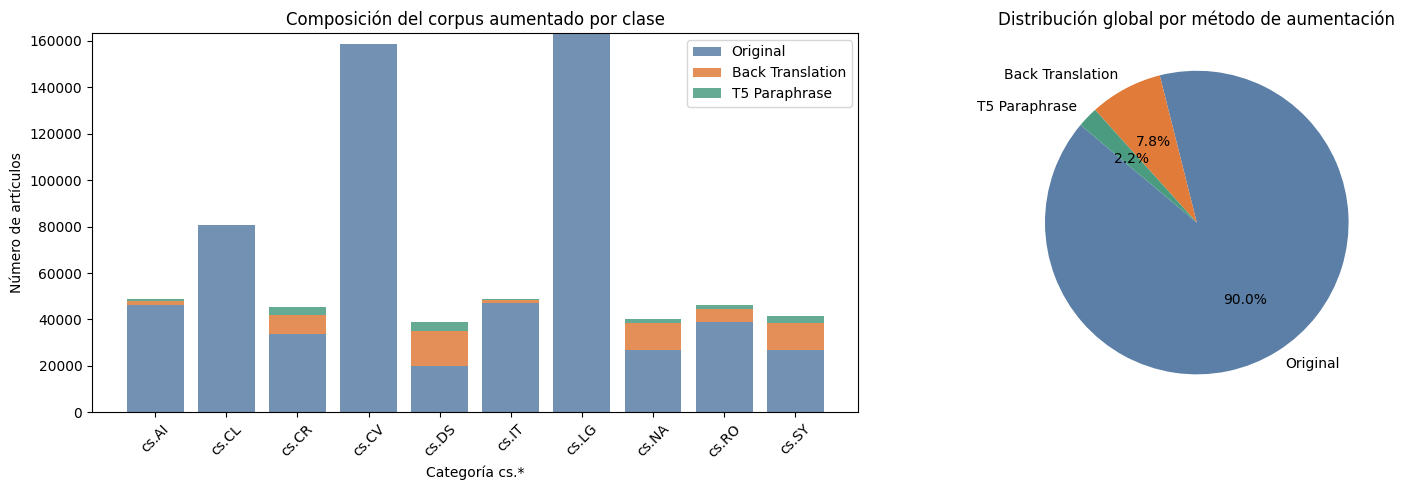

Figura guardada: corpus_aumentado_composicion.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

dist_final = df_aug.groupby(['cs_primary', 'aug_method']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#  Barras apiladas: composición por clase 
colors = {'original': '#5b7fa6', 'back_translation': '#e07b39', 't5_paraphrase': '#4a9b7f'}
bottom = np.zeros(len(dist_final))
for method in ['original', 'back_translation', 't5_paraphrase']:
    if method in dist_final.columns:
        vals = dist_final[method].values
        axes[0].bar(dist_final.index, vals, bottom=bottom,
                    label=method.replace('_', ' ').title(),
                    color=colors[method], alpha=0.85)
        bottom += vals

axes[0].set_title('Composición del corpus aumentado por clase', fontsize=12)
axes[0].set_xlabel('Categoría cs.*')
axes[0].set_ylabel('Número de artículos')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

#  Pie: distribución global de métodos 
method_totals = df_aug['aug_method'].value_counts()
wedge_colors  = [colors.get(m, '#aaa') for m in method_totals.index]
axes[1].pie(
    method_totals.values,
    labels=[m.replace('_', ' ').title() for m in method_totals.index],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Distribución global por método de aumentación', fontsize=12)

plt.tight_layout()
plt.savefig('corpus_aumentado_composicion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: corpus_aumentado_composicion.png')

In [26]:
#  Tabla resumen final 
print('=' * 65)
print('RESUMEN FASE 2 — AUMENTACIÓN DE DATOS')
print('=' * 65)
print(f'Techo de balanceo: {AUG_CEILING:,} (estrategia: raiz de clase mayoritaria)')
print(f'Dataset entrada  : arxiv_cs_top10_cleaned.parquet  ({len(df_orig):,} filas)')
print(f'Dataset salida   : arxiv_cs_top10_augmented.parquet ({len(df_aug):,} filas)')
print(f'Incremento total : +{len(df_aug)-len(df_orig):,} filas ({(len(df_aug)/len(df_orig)-1)*100:.1f}%)')
print()
print(f'{"Clase":<10} {"Original":>10} {"BT":>10} {"T5":>10} {"Total":>10}')
print('-' * 54)
for cls in sorted(dist.index):
    orig = dist[cls]
    bt_n = len(df_bt[df_bt['cs_primary'] == cls]) if len(df_bt) > 0 else 0
    t5_n = len(df_t5[df_t5['cs_primary'] == cls]) if len(df_t5) > 0 else 0
    tot  = orig + bt_n + t5_n
    print(f'{cls:<10} {orig:>10,} {bt_n:>10,} {t5_n:>10,} {tot:>10,}')
print('=' * 65)
print()
print('Archivos generados:')
print('  - arxiv_cs_top10_augmented.parquet')
print('  - distribucion_clases.png')
print('  - corpus_aumentado_composicion.png')


RESUMEN FASE 2 — AUMENTACIÓN DE DATOS
Techo de balanceo: 50,000 (estrategia: raiz de clase mayoritaria)
Dataset entrada  : arxiv_cs_top10_cleaned.parquet  (642,077 filas)
Dataset salida   : arxiv_cs_top10_augmented.parquet (713,063 filas)
Incremento total : +70,986 filas (11.1%)

Clase        Original         BT         T5      Total
------------------------------------------------------
cs.AI          46,299      1,851      1,850     50,000
cs.CL          80,665          0          0     80,665
cs.CR          33,652      8,174      8,174     50,000
cs.CV         158,670          0          0    158,670
cs.DS          19,902     15,049     15,049     50,000
cs.IT          46,983      1,509      1,508     50,000
cs.LG         163,515          0          0    163,515
cs.NA          26,775     11,613     11,612     50,000
cs.RO          38,704      5,648      5,648     50,000
cs.SY          26,912     11,544     11,544     50,000

Archivos generados:
  - arxiv_cs_top10_augmented.parquet
 